**Oreum Industries Internal Project, 2021**

---

### Oreum Copula Modelling `oreum_copula`

# 01_Background_Copulas

A very brief background on basic copulas.

## Contents

+ [Setup](#Setup)

+ [1. Demo Core Concepts of Copula Model](#1.-Demo-Core-Concepts-of-Copula-Model)


# Setup

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats, special

##### Notebook config

In [2]:
%config InlineBackend.figure_format = 'retina'
sns.set(style='darkgrid', palette='muted', context='notebook')
plt.rcParams['figure.figsize'] = 14, 2
RANDOM_SEED = 42
RNG = np.random.default_rng(seed=RANDOM_SEED)

## Local Functions and Global Vars

In [3]:
# None

## Data Connections

In [4]:
# None

---

---

# 1. Core Concepts of Copula Model

## 1.1 Walkthrough Gaussian Copula with Lognormal Marginals

See also Twiecki's blogpost [An intuitive, visual guide to copulas](https://twiecki.io/blog/2018/05/03/copulas/)

> Copulas allow us to decompose a joint probability distribution into their marginals (which by definition have no correlation) and a function which couples (hence the name) them together and thus allows us to specify the correlation seperately. The copula is that coupling function.


Demo the concept by generating synthetic data from a joint distribution that incorporates a copula

### 1.1.1 Generate random samples from multivariate normal with known covariance

In [5]:
N_SAMPLES = 100
r = -0.8                  # set a high correlation for ease of viewing later
true_cov = np.array([[1., r], [r, 1.]])  
mvnorm = stats.multivariate_normal(mean=np.zeros(2), cov=true_cov) 
df = pd.DataFrame(mvnorm.rvs(N_SAMPLES), columns=['mvn1', 'mvn2'])

##### Plot

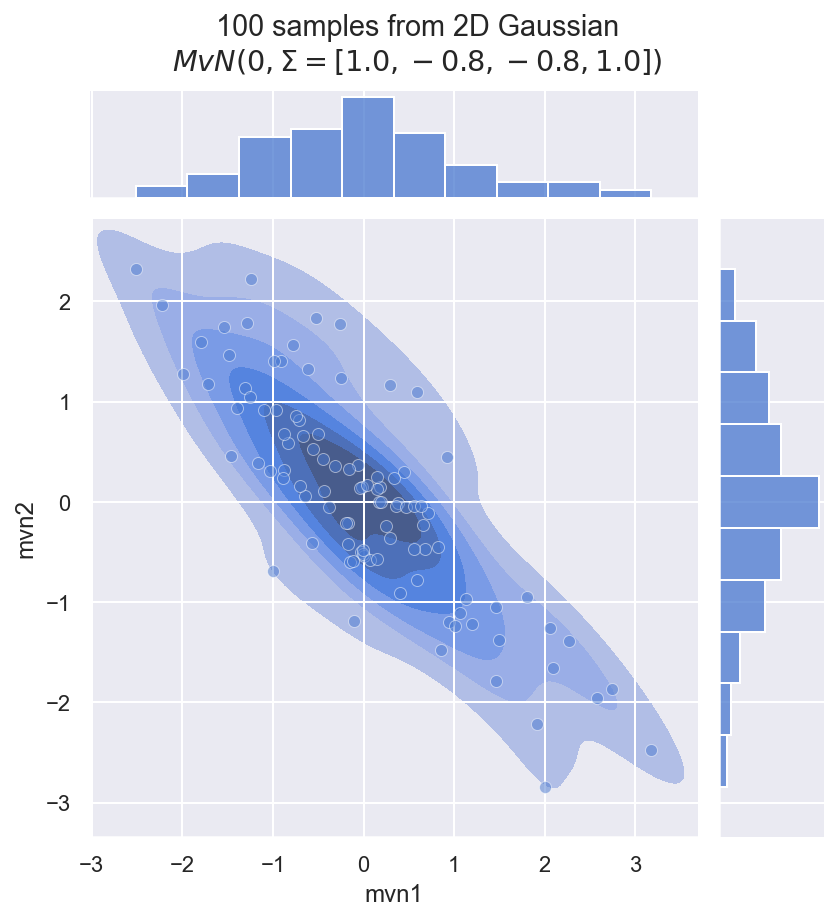

In [6]:
kde_kws = dict(zorder=0, levels=7, cut=1)
sctr_kws = dict(zorder=1, alpha=0.5)
g = sns.JointGrid(x='mvn1', y='mvn2', data=df)
g.plot_joint(sns.kdeplot, **kde_kws, fill=True)
g.plot_joint(sns.scatterplot, **sctr_kws)
g.plot_marginals(sns.histplot)
_ = g.fig.suptitle(f'{N_SAMPLES} samples from 2D Gaussian' 
                   + f'\n$MvN(0, \Sigma={true_cov.flatten().tolist()})$', y=1.06)

### 1.1.2 Transform Normal marginals to Uniform [0, 1] by passing through the Normal CDF 

In [7]:
df = pd.concat([df, pd.DataFrame(stats.norm.cdf(df[['mvn1', 'mvn2']]), 
                                 columns=['u1', 'u2'])], axis=1)

##### Plot

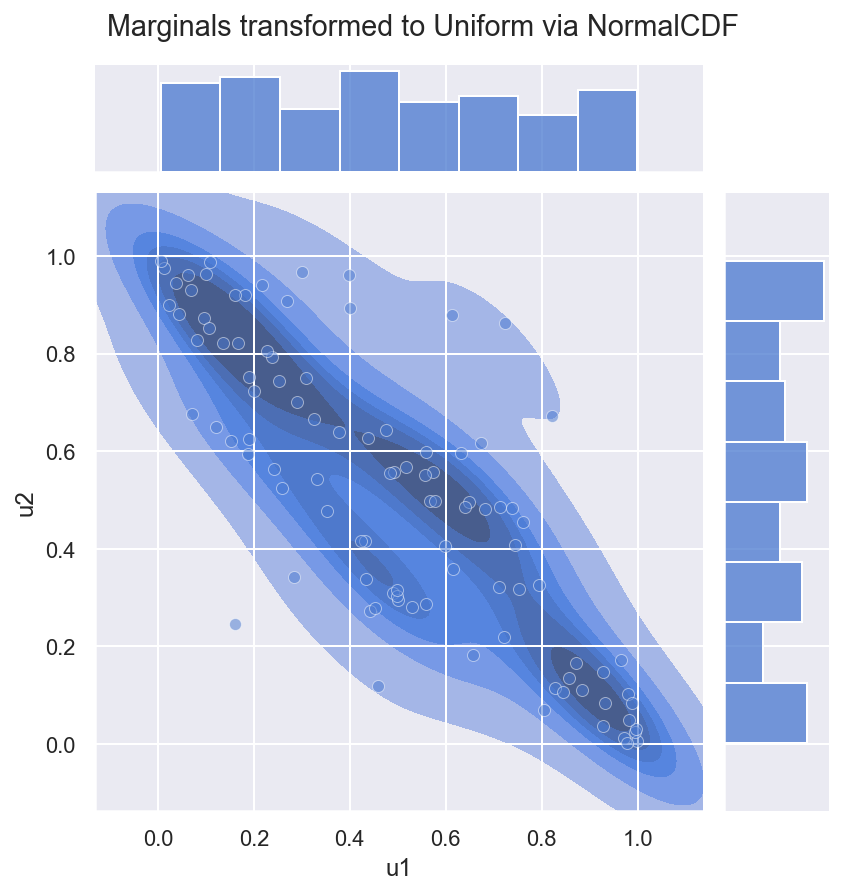

In [8]:
g = sns.JointGrid(x='u1', y='u2', data=df)
g.plot_joint(sns.kdeplot, **kde_kws, fill=True)
g.plot_joint(sns.scatterplot, **sctr_kws)
g.plot_marginals(sns.histplot)
_ = g.fig.suptitle('Marginals transformed to Uniform via NormalCDF', y=1.03)

### 1.1.3 Transform the Uniform marginals to our marginals of interest using their Inverse CDFs

Here we use Lognormals for convenience

In [9]:
MU_1 = 1
SIGMA_1 = 0.5

MU_2 = 0.4
SIGMA_2 = 0.9

m1_dist = stats.lognorm(scale=np.exp(MU_1), s=SIGMA_1)
m2_dist = stats.lognorm(scale=np.exp(MU_2), s=SIGMA_2)

# Percent Point Function (PPF) aka Quantile Function aka Inverse CDF
df['m1'] = m1_dist.ppf(df['u1'])  
df['m2'] = m2_dist.ppf(df['u2'])

##### Plot

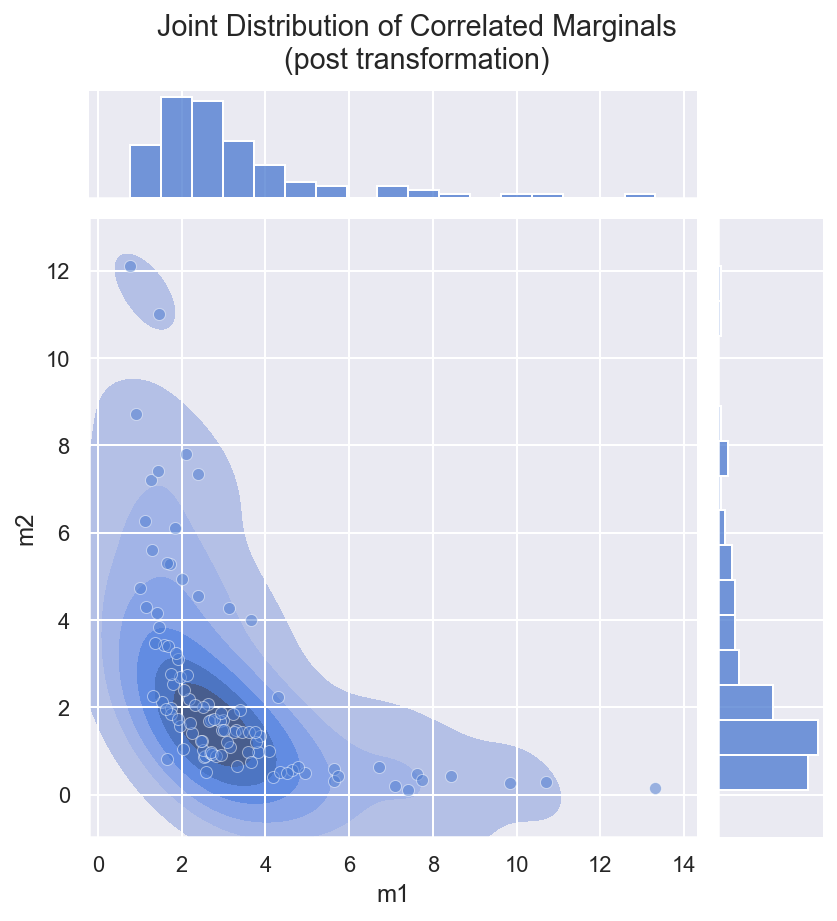

In [10]:
g = sns.JointGrid(x='m1', y='m2', data=df)
g.plot_joint(sns.kdeplot, **kde_kws, fill=True)
g.plot_joint(sns.scatterplot, **sctr_kws)
g.plot_marginals(sns.histplot)
_ = g.fig.suptitle('Joint Distribution of Correlated Marginals\n(post transformation)', y=1.06)

### 1.1.4 Compare to the joint distribution seen when the data is not jointly correlated

In [11]:
df['m1_uncorr'] = m1_dist.rvs(N_SAMPLES)
df['m2_uncorr'] = m2_dist.rvs(N_SAMPLES)

##### PLot

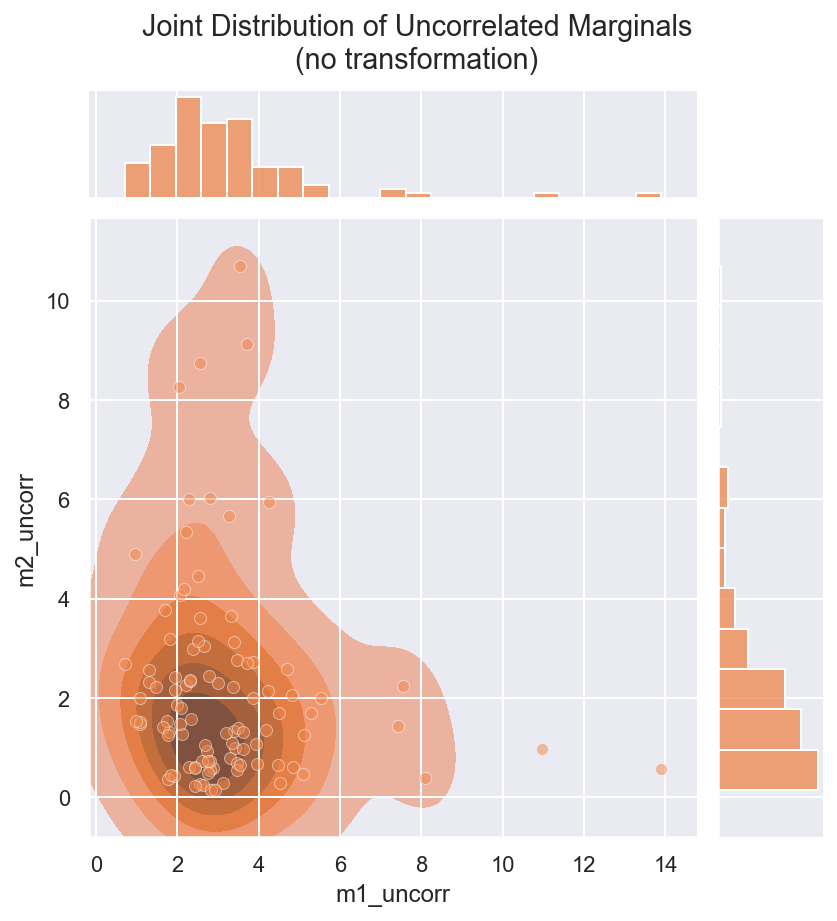

In [12]:
g = sns.JointGrid(x='m1_uncorr', y='m2_uncorr', data=df)
g.plot_joint(sns.kdeplot, **kde_kws, color='C1', fill=True)
g.plot_joint(sns.scatterplot, **sctr_kws, color='C1')
g.plot_marginals(sns.histplot, color='C1')
_ = g.fig.suptitle('Joint Distribution of Uncorrelated Marginals\n(no transformation)', y=1.06)

**Observe**:
+ Joint distribution is more spherical, loses the interdependence

In [13]:
dfp = pd.concat((df[['m1', 'm2']], 
                 df[['m1_uncorr', 'm2_uncorr']].rename(columns={'m1_uncorr':'m1', 'm2_uncorr': 'm2'})),
                axis=0, ignore_index=True)
dfp['kind'] = np.repeat(['copula_correlated', 'uncorrolated'], repeats=len(df))

##### Plot overlaying

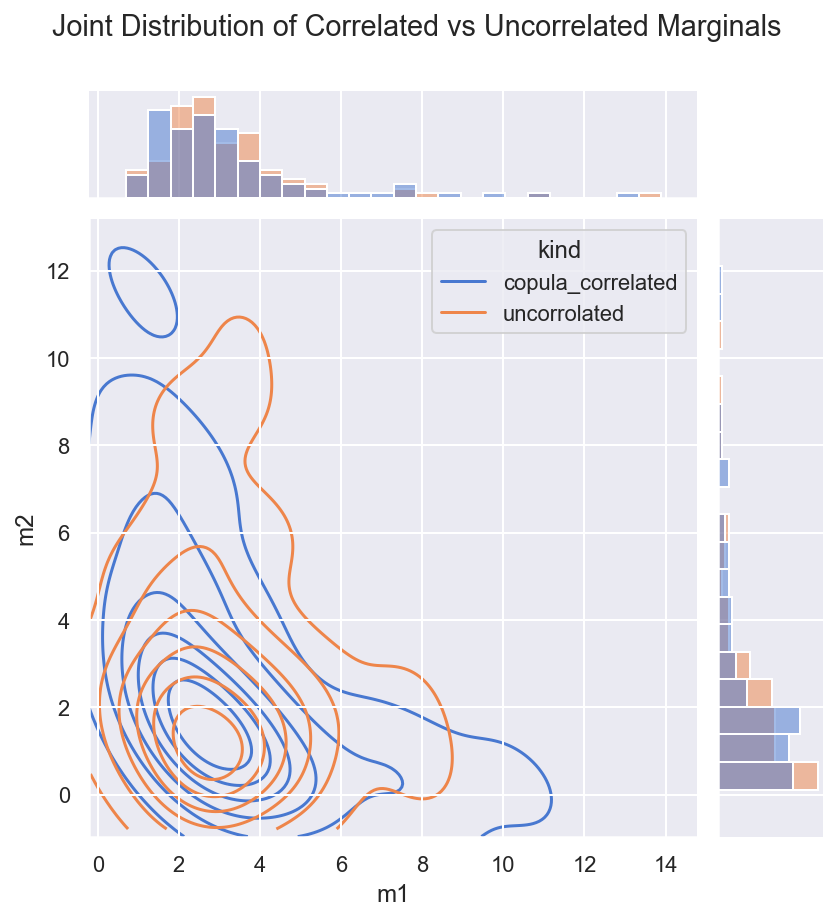

In [14]:
g = sns.JointGrid(x='m1', y='m2', hue='kind', data=dfp)
g.plot_joint(sns.kdeplot, **kde_kws)
g.plot_marginals(sns.histplot)
_ = g.fig.suptitle('Joint Distribution of Correlated vs Uncorrelated Marginals', y=1.06)

### 1.1.5 Compare impact on Compound Distribution

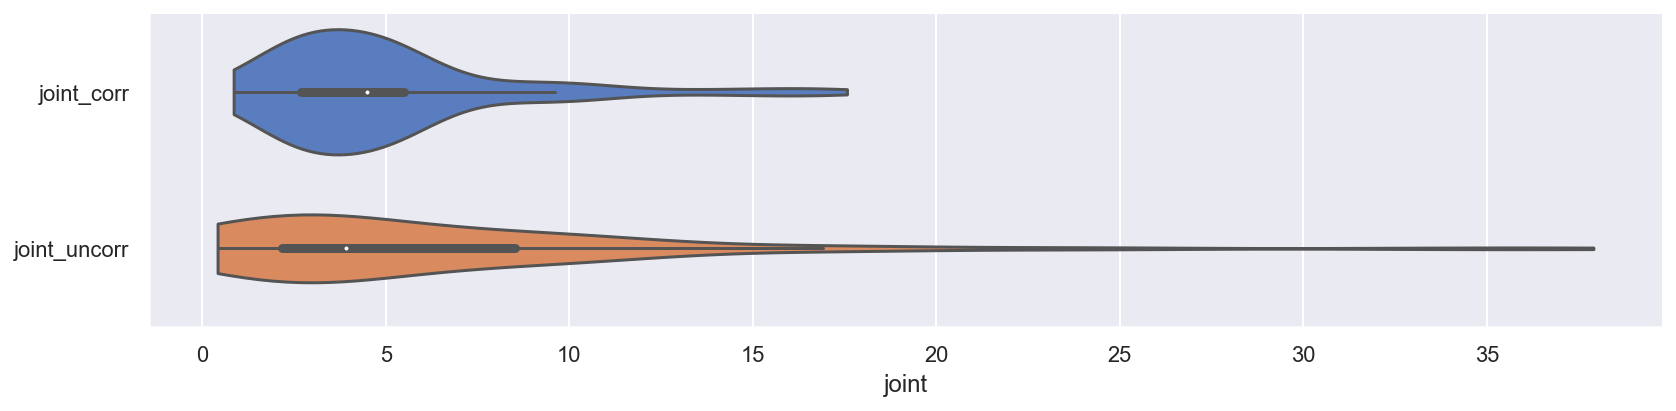

In [15]:
df['joint_corr'] = df[['m1', 'm2']].product(axis=1)
df['joint_uncorr'] = df[['m1_uncorr', 'm2_uncorr']].product(axis=1)

dfm = df[['joint_corr', 'joint_uncorr']].melt(var_name='var', value_name='joint')
gd = sns.catplot(x='joint', y='var', data=dfm, kind='violin', cut=0, height=3, aspect=4)
  
_ = gd.axes[0][0].set(ylabel='')
_ = g.fig.suptitle('Distributions of Compound Marginals\nCorrelated vs Uncorrelated Marginals', y=1.06)

Over the entire dataset this difference in compound distribution is noteworthy. If we fail to model correlated marginals we might greatly under/over-estimate the compound value.

In [16]:
df[['joint_corr', 'joint_uncorr']].mean(axis=0)

joint_corr      4.997579
joint_uncorr    6.270887
dtype: float64

---

---

# Notes

In [17]:
%load_ext watermark
%watermark -a "jonathan.sedar@oreum.io" -udtmv -iv

Author: jonathan.sedar@oreum.io

Last updated: 2021-08-31 12:08:21

Python implementation: CPython
Python version       : 3.9.6
IPython version      : 7.26.0

Compiler    : Clang 10.0.0 
OS          : Darwin
Release     : 19.6.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

matplotlib: 3.4.3
numpy     : 1.21.2
seaborn   : 0.11.2
pandas    : 1.3.2
scipy     : 1.7.1



---
**Oreum OÜ &copy; 2021**